In [1]:
#@title Install dependencies
!pip install git+https://github.com/huggingface/diffusers
!git clone https://github.com/huggingface/diffusers
!pip install -r diffusers/examples/dreambooth/requirements.txt
!pip install bitsandbytes
!pip install xformers
!pip install lit
!pip install colab-xterm
!pip uninstall -ytorch torchvision
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-pghn8cyk
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-pghn8cyk
  Resolved https://github.com/huggingface/diffusers to commit 9c7e205176c30b27c5f44ec7650a8dfcc12dde86
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
fatal: destination path 'diffusers' already exists and is not an empty directory.
Found existing installation: torch 2.6.0+cu118
Uninstalling torch-2.6.0+cu118:
  Successfully uninstalled torch-2.6.0+cu118
Found existing installation: torchvision 0.21.0+cu118
Uninstalling torchvision-0.21.0+cu118:
  Successfully uninstalled torchvision-0.21.0+cu118
Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.6.0%2Bcu118-cp312-cp312-linux_x86_64.whl.metadata (27 kB)
  Using cached https://dow

In [4]:
#@title setup accelerate with floating point 16-bit
from accelerate.utils import write_basic_config
write_basic_config(mixed_precision="fp16")

Configuration already exists at /home/eding/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.


False

In [5]:
!pip3 install torch torchvision torchaudio


## Log in to HuggingFace

In [7]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): Traceback (most recent call last):
  File "/home/eding/miniconda3/envs/

# Mount Google Drive 
For downloading person instance images and class images to workspace, and storing your model checkpoints output to google drive.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## Stable Diffusion

In [6]:
#@title Try out stable diffusion model on HuggingFace

import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

model_id = "CompVis/stable-diffusion-v1-4" #@param {type:"string"}
device = "cuda"


pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)


Loading pipeline components...: 100%|██████████| 7/7 [00:05<00:00,  1.20it/s]


100%|██████████| 50/50 [00:10<00:00,  4.69it/s]


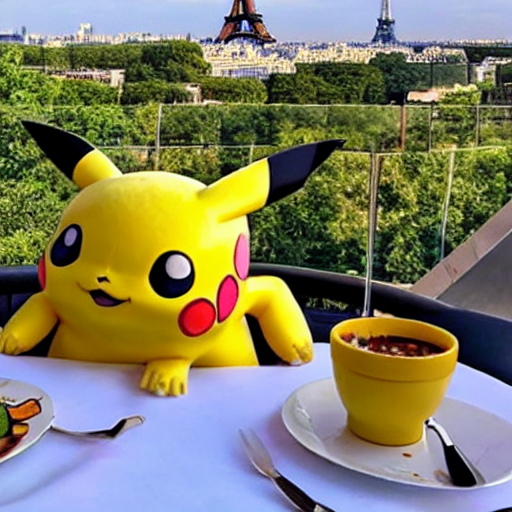

In [7]:
prompt = "A pikachu fine dining with a view to the Eiffel Tower" #@param {type:"string"}
image = pipe(prompt).images[0]  
    
display(image)

## Use Microsoft/Promptist to refine prompt

In [9]:
# Load Microsoft/Promptist pipeline
from transformers import pipeline

promptist_pipe = pipeline("text-generation", model="microsoft/Promptist")

Device set to use cuda:0


In [10]:
prompt = 'A pikachu fine dining with a view to the Eiffel Tower' #@param {type:"string"}
result = promptist_pipe('A pikachu fine dining with a view to the Eiffel Tower')
print(f'Optimized Prompt: {result[0]["generated_text"]}')

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Optimized Prompt: A pikachu fine dining with a view to the Eiffel Tower in a fortified fortified fortified fortified fortified town, portrait painting by greg rutkowski, artstation, digital painting, artstation, concept art, matte painting, highly detailed


100%|██████████| 50/50 [00:10<00:00,  4.71it/s]


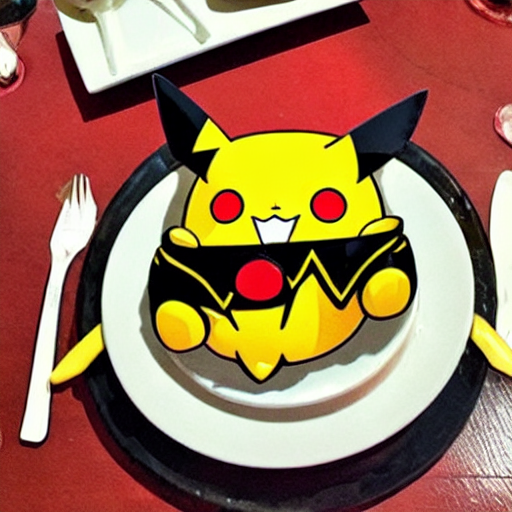

In [11]:
image = pipe(prompt).images[0]  
    
display(image)

## **NOTE: Restart session to clear RAM for the latter execution.**

## DreamBooth Code setup
More details of the training script and parameters can be found in the following links: \\
https://github.com/huggingface/diffusers/tree/main/examples/dreambooth \\
https://huggingface.co/docs/diffusers/en/training/dreambooth

For guidance of selecting training and inference paramters, you find more information in this link: \\
https://huggingface.co/blog/dreambooth

In [3]:
#@title Generate command for training model

#@markdown Pre-trained diffusion models from HuggingFace
model_name = "CompVis/stable-diffusion-v1-4" #@param {type:"string"}

#@markdown Directory containing your instance images
instance_dir = "./instance_dir" #@param {type:"string"}

#@markdown Directory containing your class images
class_dir = "./class_images" #@param {type:"string"}

#@markdown Directory for storing model output and checkpoints
output_dir = "./output_dir" #@param {type:"string"}

#@markdown Your instance prompt
instance_prompt = "a sks person" #@param {type:"string"}

#@markdown Your class prompt
class_prompt = "a person" #@param {type:"string"}

#@markdown Number of class images use in training
num_class_images = 1500 #@param {type:"integer"}

#@markdown Training steps use in training
max_training_steps = 500 #@param {type:"integer"}

#@markdown Checkpoint steps (frequency of saving checkpoints)
checkpointing_steps = 100 #@param {type:"integer"}

#@markdown Learning rate use in training
learning_rate = 0.000002 #@param {type:"number"}

#@markdown Resume to checkpoint
resume_checkpoint = False #@param {type:"boolean"}
checkpoint_number = 100 #@param {type:"number"}

# export directories for current process, needed for later use
!export MODEL_NAME=model_name
!export INSTANCE_DIR=instance_dir
!export CLASS_DIR=class_dir
!export OUTPUT_DIR=output_dir
!export INSTANCE_PROMPT=instance_prompt
!export CLASS_PROMPT=class_prompt

# create training command
training_command = f'''
export MODEL_NAME="{model_name}"
export INSTANCE_DIR="{instance_dir}"
export CLASS_DIR="{class_dir}"
export OUTPUT_DIR="{output_dir}"
export INSTANCE_PROMPT="{instance_prompt}"
export CLASS_PROMPT="{class_prompt}"
export NUM_CLASS_IMAGES={num_class_images}
export MAX_TRAIN_STEPS={max_training_steps}
export CHECKPOINTING_STEPS={checkpointing_steps}
export LEARNING_RATE={learning_rate}

accelerate launch --mixed_precision="fp16" "./diffusers/examples/dreambooth/train_dreambooth.py" \\
  --pretrained_model_name_or_path="$MODEL_NAME"  \\
  --train_text_encoder \\
  --instance_data_dir="$INSTANCE_DIR" \\
  --class_data_dir="$CLASS_DIR" \\
  --output_dir="$OUTPUT_DIR" \\
  --with_prior_preservation \\
  --prior_loss_weight=1.0 \\
  --instance_prompt="$INSTANCE_PROMPT" \\
  --class_prompt="$CLASS_PROMPT" \\
  --resolution=512 \\
  --train_batch_size=2 \\
  --gradient_accumulation_steps=2 \\
  --gradient_checkpointing \\
  --use_8bit_adam \\
  --learning_rate=$LEARNING_RATE \\
  --lr_scheduler="constant" \\
  --lr_warmup_steps=0 \\
  --num_class_images=$NUM_CLASS_IMAGES \\
  --max_train_steps=$MAX_TRAIN_STEPS \\
  --checkpointing_steps=$CHECKPOINTING_STEPS \\
  --enable_xformers_memory_efficient_attention \\
  --set_grads_to_none '''

if(resume_checkpoint):
  training_command += f'\\\n  --resume_from_checkpoint="{output_dir}/checkpoint-{checkpoint_number}"'

print(training_command)


export MODEL_NAME="CompVis/stable-diffusion-v1-4"
export INSTANCE_DIR="./instance_dir"
export CLASS_DIR="./class_images"
export OUTPUT_DIR="./output_dir"
export INSTANCE_PROMPT="a sks person"
export CLASS_PROMPT="a person"
export NUM_CLASS_IMAGES=1500
export MAX_TRAIN_STEPS=500
export CHECKPOINTING_STEPS=100
export LEARNING_RATE=2e-06

accelerate launch --mixed_precision="fp16" "./diffusers/examples/dreambooth/train_dreambooth.py" \
  --pretrained_model_name_or_path="$MODEL_NAME"  \
  --train_text_encoder \
  --instance_data_dir="$INSTANCE_DIR" \
  --class_data_dir="$CLASS_DIR" \
  --output_dir="$OUTPUT_DIR" \
  --with_prior_preservation \
  --prior_loss_weight=1.0 \
  --instance_prompt="$INSTANCE_PROMPT" \
  --class_prompt="$CLASS_PROMPT" \
  --resolution=512 \
  --train_batch_size=2 \
  --gradient_accumulation_steps=2 \
  --gradient_checkpointing \
  --use_8bit_adam \
  --learning_rate=$LEARNING_RATE \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --num_class_images=$NUM_C

## Copy-Past-and-Run the above code in this xterm window

In [5]:
%load_ext colabxterm
%xterm


The colabxterm extension is already loaded. To reload it, use:
  %reload_ext colabxterm


Launching Xterm...

🚀  Listen to 10002
{"success": true, "reason": null}



Uncaught exception GET /out (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:10000', method='GET', uri='/out', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/eding/miniconda3/envs/157b/lib/python3.12/site-packages/tornado/web.py", line 1790, in _execute
    result = await result
             ^^^^^^^^^^^^
  File "/home/eding/miniconda3/envs/157b/lib/python3.12/site-packages/colabxterm/xterm.py", line 25, in get
    await self.flush()
tornado.iostream.StreamClosedError: Stream is closed
Cannot send error response after headers written
404 GET /favicon.ico (127.0.0.1) 0.22ms
404 GET /favicon.ico (127.0.0.1) 0.18ms


Run this block of code during training to avoid Google Colab from timing out. \
NOTE! If you killed this cell, it will also kill the xterm process in the above cell. (Only kill this cell if your training is complete.)

In [3]:
#@title Run this code to prevent runtime timeout
from time import sleep
from datetime import datetime
while 1:
  print('Preventing runtime timeout... Current time:', datetime.now())
  sleep(60)

Preventing runtime timeout... Current time: 2025-02-19 21:25:13.422818


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/miniconda3/envs/157b/lib/python3.13/site-packages/colabxterm/__main__.py", line 14, in <module>
    term.open()
    ~~~~~~~~~^^
  File "/opt/miniconda3/envs/157b/lib/python3.13/site-packages/colabxterm/xterm.py", line 83, in open
    tornado.ioloop.IOLoop.current().start()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/miniconda3/envs/157b/lib/python3.13/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/miniconda3/envs/157b/lib/python3.13/asyncio/base_events.py", line 678, in run_forever
    self._run_once()
    ~~~~~~~~~~~~~~^^
  File "/opt/miniconda3/envs/157b/lib/python3.13/asyncio/base_events.py", line 1995, in _run_once
    event_list = self._selector.select(timeout)
  File "/opt/miniconda3/envs/157b/lib/python3.13/selectors

KeyboardInterrupt: 

## Try out your
Test out your model by giving it various prompt. (e.g. "a sks person with blue hair", "a sks person wearing chef outfit") \
If your model is not affected by your prompt, then most likely, your model has overfitted to the training images. In this case, try out an earlier checkpoint. 

Load model with this cell

In [4]:
#@title Load the model currently at the root of the output directory

#@markdown scheduler for sampling images during inference (see https://huggingface.co/blog/dreambooth#effect-of-schedulers)
scheduler_name = "DDIM" #@param ["DDIM", "DPMSolverMultistep"]

#@markdown Resume to checkpoint
output_dir = "/content/output_dir" #@param {type:"string"}
checkpoint_number = 300 #@param {type:"number"}

from diffusers import (
    StableDiffusionPipeline,
    DPMSolverMultistepScheduler,
    DDIMScheduler
)
import torch

checkpoint_dir = f'{output_dir}/checkpoint-{checkpoint_number}'

schedulers = {
    'DPMSolverMultistep': DPMSolverMultistepScheduler.from_pretrained,
    'DDIM': DDIMScheduler.from_pretrained
}

scheduler = schedulers[scheduler_name]

pipe = StableDiffusionPipeline.from_pretrained(output_dir, 
          scheduler=scheduler(output_dir, subfolder="scheduler"),
          torch_dtype=torch.float16
        ).to("cuda")

/opt/miniconda3/envs/157b/lib/python3.13/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'
import error: No module named 'triton'


OSError: We couldn't connect to 'https://huggingface.co' to load this model, couldn't find it in the cached files and it looks like /content/output_dir is not the path to a directory containing a scheduler_config.json file.
Checkout your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/diffusers/installation#offline-mode'.

In [ ]:
#@title Generate image from prompt

#@markdown Prompt use to generate images
prompt = "a sks person wearing chef uniform" #@param {type:"string"}

#@markdown Number of inference steps
num_inference_steps = 50 #@param {type:"integer"}

#@markdown Guidance scale
guidance_scale = 7.5 #@param {type:"number"}

#@markdown Number of image to generate
num_images = 3 #@param {type:"integer"}

from IPython.display import display
for _ in range(num_images):
  image = pipe(prompt, 
                num_inference_steps=num_inference_steps, 
                guidance_scale=guidance_scale
               ).images[0]
  display(image)

In [ ]:
#@title Save your fine-tuned model to your huggingface-hub (Code from [HuggingFace Stable Diffusion Dreambooth Concepts Library](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/sd_dreambooth_training.ipynb) with modifications)

#@markdown HuggingFace repository name where the model will be saved to
repo_name = "" #@param {type:"string"}

import os
from slugify import slugify
from huggingface_hub import HfApi, HfFolder, CommitOperationAdd
from huggingface_hub import create_repo
from IPython.display import display_markdown

# some api and huggingface account setup
api = HfApi()
your_username = api.whoami()["name"]

# save the model in the root of the model output folder
os.makedirs("fp16_model",exist_ok=True)
pipe.save_pretrained("fp16_model")

# retrieve your huggingFace repo and upload model
repo_id = f"{your_username}/{slugify(repo_name)}"


with open(HfFolder.path_token, 'r') as fin: hf_token = fin.read();


readme_text = f'''---
license: creativeml-openrail-m
tags:
- text-to-image
---
### Fine-tuned Stable Diffusion via Dreambooth
#### model by {api.whoami()["name"]}
A fine-tuned Stable Diffusion via Dreambooth
'''

# Save the readme to a file
readme_file = open("README.md", "w")
readme_file.write(readme_text)
readme_file.close()

# Save the token identifier to a file
text_file = open("token_identifier.txt", "w")
text_file.close()
operations = [
  CommitOperationAdd(path_in_repo="token_identifier.txt", path_or_fileobj="token_identifier.txt"),
  CommitOperationAdd(path_in_repo="README.md", path_or_fileobj="README.md"),
]

# create private repo
create_repo(repo_id, private=True, token=hf_token)

# commit and upload model 
api.create_commit(
  repo_id=repo_id,
  operations=operations,
  commit_message=f"Uploaded fine-tuned model.",
  token=hf_token
)
api.upload_folder(
  folder_path="fp16_model",
  path_in_repo="",
  repo_id=repo_id,
  token=hf_token
)

  
print(f'## Your model was saved successfully. [Click here to access it](https://huggingface.co/{repo_id})')

In [ ]:
#@title DELETE checkpoint to free up space

#@markdown Checkpoint to be deleted
delete_confirmation = False #@param {type:"boolean"}
checkpoint_number = None #@param {type:"number"}

import shutil

if(delete_confirmation):
  shutil.rmtree(f'{output_dir}/checkpoint-{checkpoint_number}')
